尝试了其他几种模型后，发现其表现都不尽如人意，考虑到直方图中表现出的头部快速下降，后平稳再下降的趋势，我们决定使用分段混合式模型:
模型由三段组成，第一段为指数衰减段，第二段为均匀分布段，第三段为指数衰减段，具体解析式和参数表示见下：
针对您要求的**三段式“衰减-平台-衰减”模型**（Segmented Decay-Plateau-Decay Model），以下是该模型的数学解析式、参数表达以及最大似然估计（MLE）的详细求解过程。

---

### 一、 模型解析式 (Analytical Expression)

该模型将随机变量 $X$ 的取值范围 $[a, b]$ 分为三个阶段，其概率密度函数（PDF）定义如下：

#### 1. 概率密度函数 $f(x)$

$$
f(x|\theta) = 
\begin{cases} 
k \cdot e^{\lambda_1(\tau_1 - x)} & a \le x < \tau_1 & \text{(第一段：指数衰减)} \\
k & \tau_1 \le x \le \tau_2 & \text{(第二段：均匀平台)} \\
k \cdot e^{-\lambda_2(x - \tau_2)} & \tau_2 < x \le b & \text{(第三段：指数衰减)} \\
0 & \text{其他}
\end{cases}
$$

其中，$k$ 是**归一化常数**（即平台高度），由全概率公理 $\int_a^b f(x)dx = 1$ 确定。

#### 2. 归一化常数 $k$ 的推导

计算三个分段区域的面积：
- **Area 1**: $\int_a^{\tau_1} k e^{\lambda_1(\tau_1 - x)} dx = k \left[ \frac{e^{\lambda_1(\tau_1 - a)} - 1}{\lambda_1} \right]$
- **Area 2**: $\int_{\tau_1}^{\tau_2} k dx = k(\tau_2 - \tau_1)$
- **Area 3**: $\int_{\tau_2}^b k e^{-\lambda_2(x - \tau_2)} dx = k \left[ \frac{1 - e^{-\lambda_2(b - \tau_2)}}{\lambda_2} \right]$

令总面积等于 1，解得 $k$：
$$k = \left[ \frac{e^{\lambda_1(\tau_1 - a)} - 1}{\lambda_1} + (\tau_2 - \tau_1) + \frac{1 - e^{-\lambda_2(b - \tau_2)}}{\lambda_2} \right]^{-1}$$

#### 3. 累积分布函数 $F(x)$

$$
F(x) = 
\begin{cases} 
k \frac{e^{\lambda_1(\tau_1 - a)} - e^{\lambda_1(\tau_1 - x)}}{\lambda_1} & a \le x < \tau_1 \\
F(\tau_1) + k(x - \tau_1) & \tau_1 \le x \le \tau_2 \\
F(\tau_2) + k \frac{1 - e^{-\lambda_2(x - \tau_2)}}{\lambda_2} & \tau_2 < x \le b
\end{cases}
$$

---

### 二、 参数表达 (Parameters)

模型包含以下 4 个待估参数（假设边界 $a, b$ 已知）：

1.  **$\tau_1$ (第一转折点)**：数据从初始衰减进入稳定平台的临界值。
2.  **$\tau_2$ (第二转折点)**：数据从稳定平台进入末端衰减的临界值。要求 $a < \tau_1 < \tau_2 < b$。
3.  **$\lambda_1$ (起始衰减率)**：控制首段下降的陡峭程度。$\lambda_1 > 0$ 时，曲线从左向右下降。
4.  **$\lambda_2$ (末端衰减率)**：控制尾段下降的陡峭程度。$\lambda_2 > 0$ 时，曲线从平台向右下降。

---

### 三、 最大似然估计 (MLE) 求解过程

给定一组独立同分布（i.i.d.）的观测样本 $x = \{x_1, x_2, ..., x_n\}$。

#### 1. 构建似然函数 $L(\theta)$

$$L(\theta) = \prod_{i=1}^{n} f(x_i | \tau_1, \tau_2, \lambda_1, \lambda_2)$$

#### 2. 构建对数似然函数 $\ell(\theta)$

为了简化计算，取对数：
$$\ell(\theta) = \sum_{i=1}^{n} \ln f(x_i)$$

根据 $x_i$ 落在的不同区间进行分类计数：
- 令 $n_1, n_2, n_3$ 分别为落在三个区间的样本数量。
- 展开对数项：
$$\ell(\theta) = n \ln k + \sum_{x_i \in [a, \tau_1)} \lambda_1(\tau_1 - x_i) + \sum_{x_i \in (\tau_2, b]} -\lambda_2(x_i - \tau_2)$$

其中 $k$ 是关于所有 4 个参数的复杂函数。

#### 3. 求解导数（一阶条件）

理论上，我们需要对各参数求偏导并令其为 0：
- $\frac{\partial \ell}{\partial \lambda_1} = 0, \quad \frac{\partial \ell}{\partial \lambda_2} = 0$
- $\frac{\partial \ell}{\partial \tau_1} = 0, \quad \frac{\partial \ell}{\partial \tau_2} = 0$

**注意**：由于 $k$ 的表达式包含指数项且分段点 $\tau$ 出现在求和符号的指示函数中，该方程组没有解析解（Closed-form solution）。

#### 4. 数值优化算法过程

在实际计算中，我们用 `L-BFGS-B` 算法来最大化 $\ell(\theta)$：

1.  **约束条件**：
    *   $a + \epsilon \le \tau_1 \le \tau_2 - \epsilon$
    *   $\tau_1 + \epsilon \le \tau_2 \le b - \epsilon$
    *   $\lambda_1, \lambda_2 > 0$
2.  **目标函数**：最小化负对数似然函数 $-\ell(\theta)$。
3.  **搜索过程**：
    *   算法在四维空间搜索 $(\tau_1, \tau_2, \lambda_1, \lambda_2)$。
    *   每一轮迭代都会根据当前的参数重新计算归一化系数 $k$。
    *   利用梯度下降或拟牛顿法寻找使样本出现概率最大的参数组合。



Running Analysis for Person1...


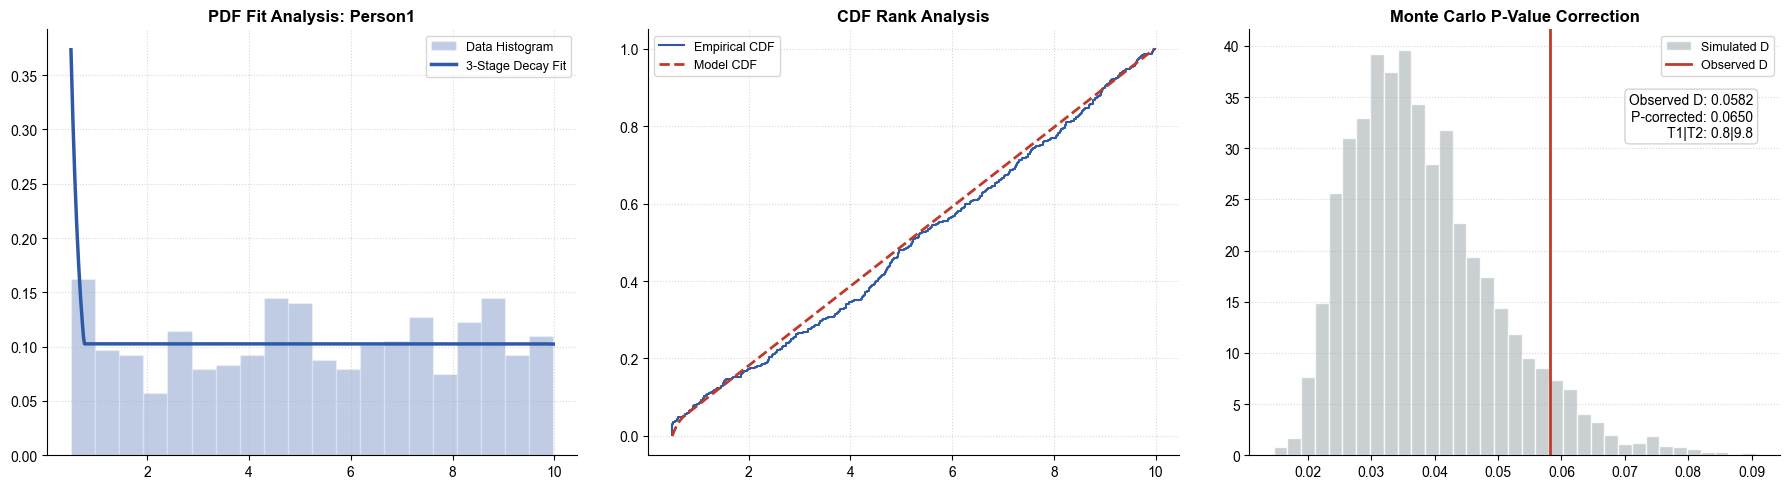

Analysis for Person1 completed. P-corrected: 0.0650


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import kstest
import io
df = pd.read_csv('envelopes.csv')
def analyze_person_distribution(person_num):
    """
    全过程分析函数：拟合三段式(衰减-平台-衰减)分布并进行蒙特卡洛P值修正
    参数 person_num: 整数，对应 Person1, Person2...
    """
    # --- 1. 数据提取与预处理 ---
    target_col = f'Person{person_num}'
    # 假设 df 已经在全局作用域中定义
    df_clean = df[df['Trial'] != 'Total'].copy()
    data = df_clean[target_col].astype(float).values
    n_samples = len(data)
    v_min, v_max = data.min(), data.max()

    # --- 2. 模型核心数学定义 ---
    def get_params(t1, t2, l1, l2, a, b):
        area1 = (np.exp(l1 * (t1 - a)) - 1) / max(l1, 1e-10)
        area2 = t2 - t1
        area3 = (1 - np.exp(-l2 * (b - t2))) / max(l2, 1e-10)
        k = 1.0 / (area1 + area2 + area3)
        p1 = k * area1
        p2 = p1 + k * area2
        return k, p1, p2

    def pdf_func(x, t1, t2, l1, l2, a, b):
        k, _, _ = get_params(t1, t2, l1, l2, a, b)
        pdf = np.zeros_like(x)
        m1, m2, m3 = (x < t1), (x >= t1) & (x <= t2), (x > t2)
        pdf[m1] = k * np.exp(l1 * (t1 - x[m1]))
        pdf[m2] = k
        pdf[m3] = k * np.exp(-l2 * (x[m3] - t2))
        return pdf

    def cdf_func(x, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        cdf = np.zeros_like(x)
        m1 = (x >= a) & (x < t1)
        cdf[m1] = k * (np.exp(l1 * (t1 - a)) - np.exp(l1 * (t1 - x[m1]))) / max(l1, 1e-10)
        m2 = (x >= t1) & (x <= t2)
        cdf[m2] = p1 + k * (x[m2] - t1)
        m3 = (x > t2) & (x <= b)
        cdf[m3] = p2 + k * (1 - np.exp(-l2 * (x[m3] - t2))) / max(l2, 1e-10)
        cdf[x > b] = 1.0
        return np.clip(cdf, 0, 1)

    def rvs_func(size, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        u = np.random.random(size)
        res = np.zeros(size)
        i1, i2, i3 = (u < p1), (u >= p1) & (u < p2), (u >= p2)
        res[i1] = t1 - np.log(np.exp(l1 * (t1 - a)) - u[i1] * l1 / k) / max(l1, 1e-10)
        res[i2] = t1 + (u[i2] - p1) / k
        res[i3] = t2 - np.log(1 - (u[i3] - p2) * l2 / k) / max(l2, 1e-10)
        return np.clip(res, a, b)

    # --- 3. 拟合与蒙特卡洛模拟 ---
    def nll(p, obs):
        t1, t2, l1, l2 = p
        if t1 >= t2 or t1 <= v_min or t2 >= v_max or l1 <= 0 or l2 <= 0: return 1e12
        return -np.sum(np.log(pdf_func(obs, t1, t2, l1, l2, v_min, v_max) + 1e-12))

    # 初始拟合
    bnds = [(v_min+0.2, v_max-0.2), (v_min+0.2, v_max-0.2), (0.01, 5), (0.01, 5)]
    res_obs = minimize(nll, x0=[v_min+1, v_max-1, 0.5, 0.5], args=(data,), bounds=bnds)
    t1_o, t2_o, l1_o, l2_o = res_obs.x
    
    # 观测到的 D 统计量
    d_obs = kstest(data, lambda x: cdf_func(x, t1_o, t2_o, l1_o, l2_o, v_min, v_max)).statistic

    # 蒙特卡洛 5000 次
    n_sims = 5000
    d_sims = []
    print(f"Running Analysis for {target_col}...")
    for _ in range(n_sims):
        s_data = rvs_func(n_samples, t1_o, t2_o, l1_o, l2_o, v_min, v_max)
        # 快速拟合获取模拟 D 值
        s_res = minimize(nll, x0=[t1_o, t2_o, l1_o, l2_o], args=(s_data,), bounds=bnds, tol=1e-1)
        d_sims.append(kstest(s_data, lambda x: cdf_func(x, *s_res.x, v_min, v_max)).statistic)

    p_corrected = np.mean(np.array(d_sims) >= d_obs)

    # --- 4. 绘图 (比例 18:5) ---
    plt.rcParams['font.sans-serif'] = ['Arial']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
    x_grid = np.linspace(v_min, v_max, 500)

    # Ax1: Histogram & PDF
    ax1.hist(data, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
    ax1.plot(x_grid, pdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), color='#2E59A7', lw=2.5, label='3-Stage Decay Fit')
    ax1.set_title(f'PDF Fit Analysis: {target_col}', fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(True, linestyle=':', alpha=0.5); ax1.spines[['top','right']].set_visible(False)

    # Ax2: CDF Comparison
    ax2.step(np.sort(data), np.arange(1, n_samples+1)/n_samples, label='Empirical CDF', color='#2E59A7', lw=1.5)
    ax2.plot(x_grid, cdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), label='Model CDF', color='#C0392B', ls='--', lw=2)
    ax2.set_title('CDF Rank Analysis', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, linestyle=':', alpha=0.5); ax2.spines[['top','right']].set_visible(False)

    # Ax3: MC Rank
    ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D')
    ax3.axvline(d_obs, color='#C0392B', lw=2, label='Observed D')
    ax3.set_title('Monte Carlo P-Value Correction', fontweight='bold')
    info = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nT1|T2: {t1_o:.1f}|{t2_o:.1f}'
    ax3.text(0.95, 0.85, info, transform=ax3.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7, ec='#BDC3C7'))
    ax3.legend(fontsize=9); ax3.grid(True, linestyle=':', alpha=0.5, axis='y'); ax3.spines[['top','right']].set_visible(False)

    plt.tight_layout(w_pad=3.0)
    plt.show()
    
    print(f"Analysis for {target_col} completed. P-corrected: {p_corrected:.4f}")

# 分析第一个人
analyze_person_distribution(1)



Running Analysis for Person2...


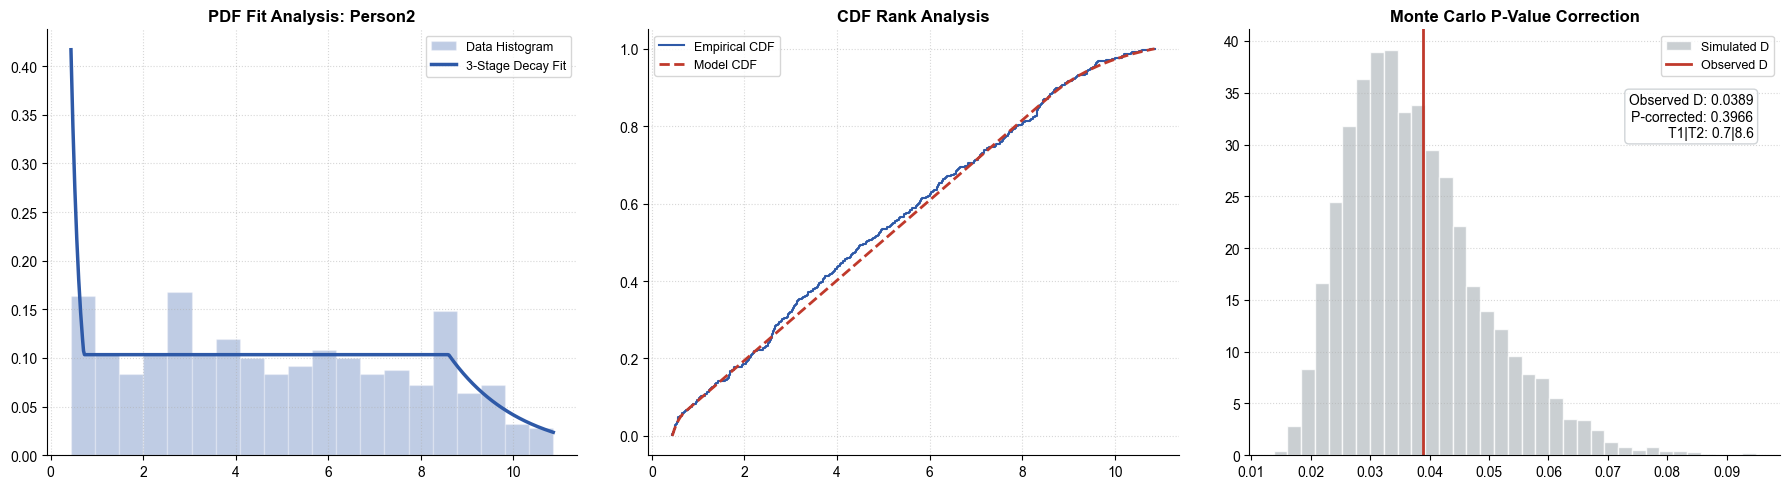

Analysis for Person2 completed. P-corrected: 0.3966


In [29]:
analyze_person_distribution(2)

Running Analysis for Person3...


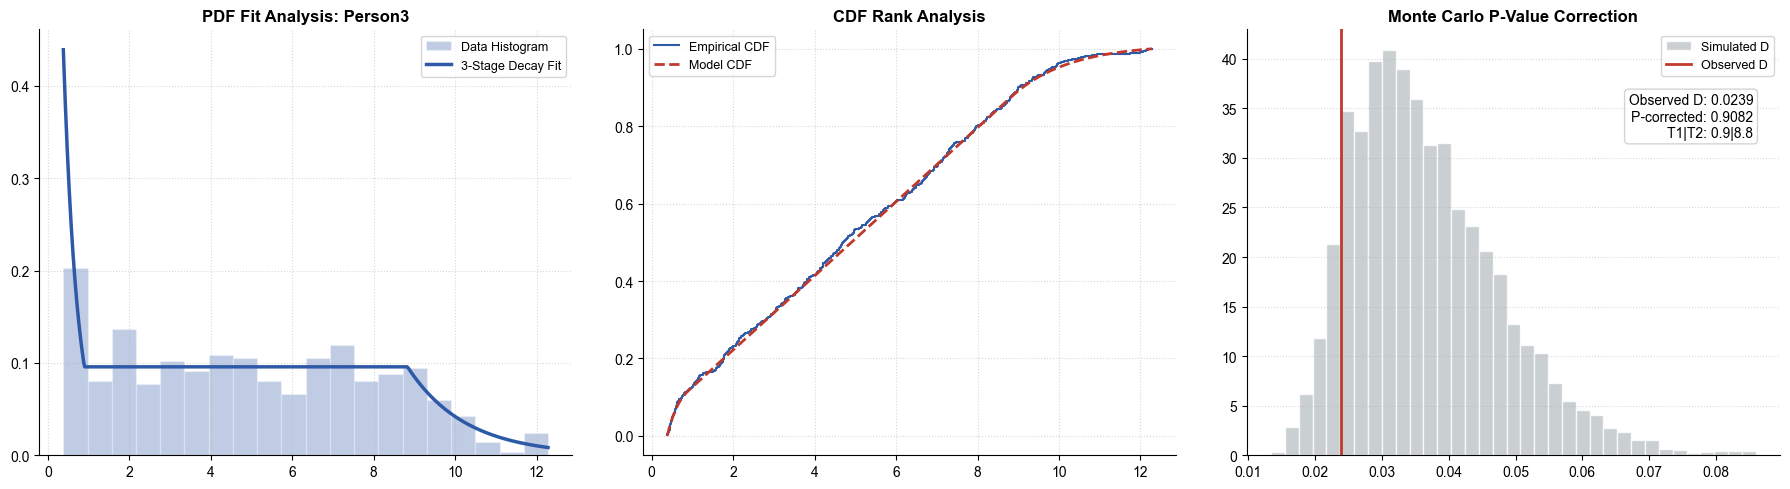

Analysis for Person3 completed. P-corrected: 0.9082


In [30]:
analyze_person_distribution(3)

Running Analysis for Person4...


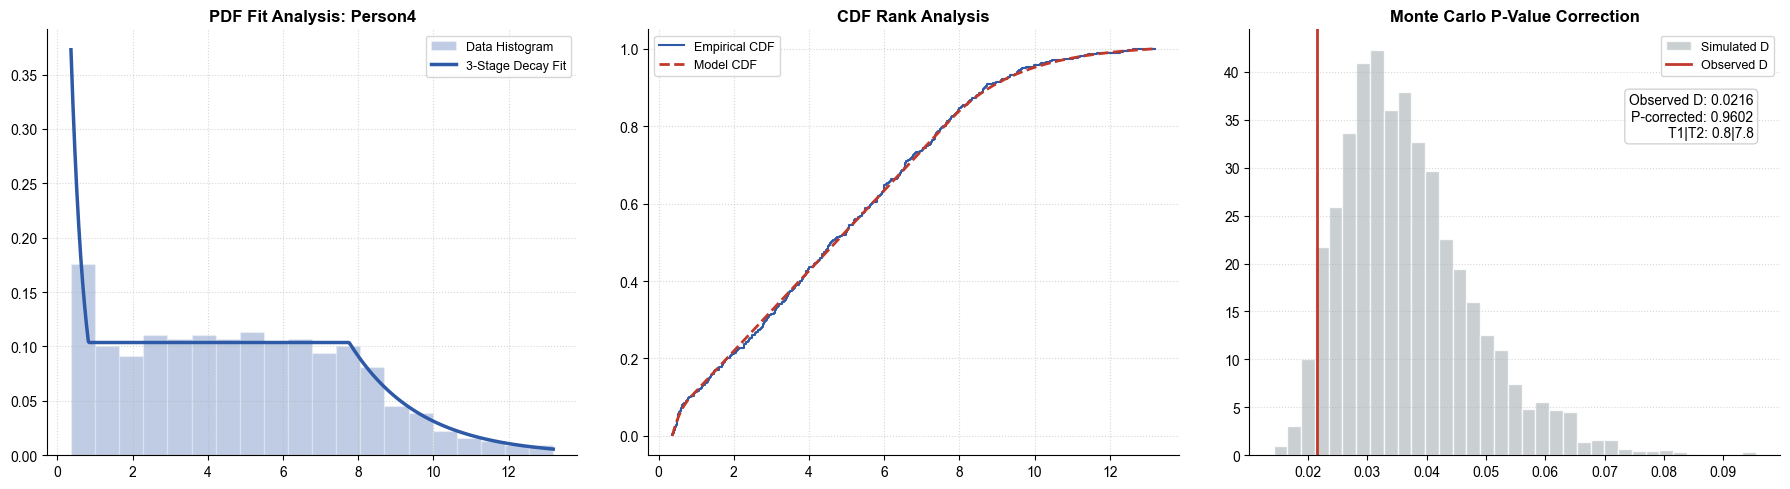

Analysis for Person4 completed. P-corrected: 0.9602


In [31]:
analyze_person_distribution(4)

Running Analysis for Person5...


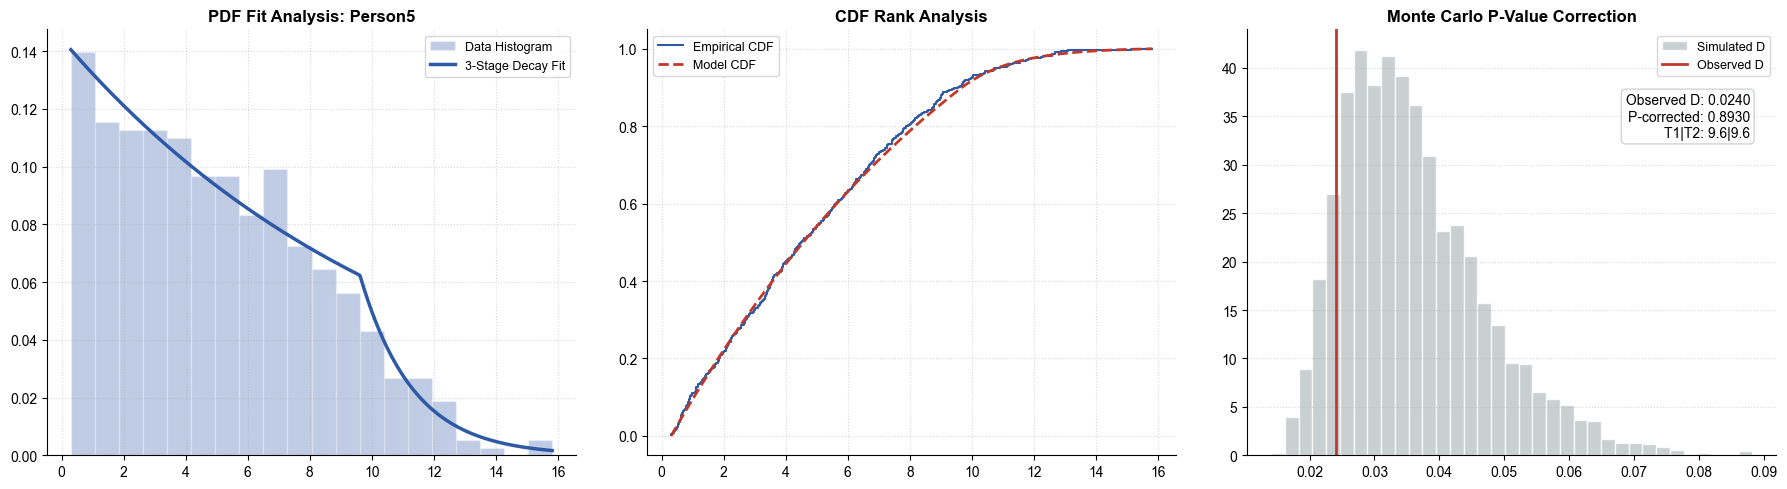

Analysis for Person5 completed. P-corrected: 0.8930


In [32]:
analyze_person_distribution(5)

Running Analysis for Person6...


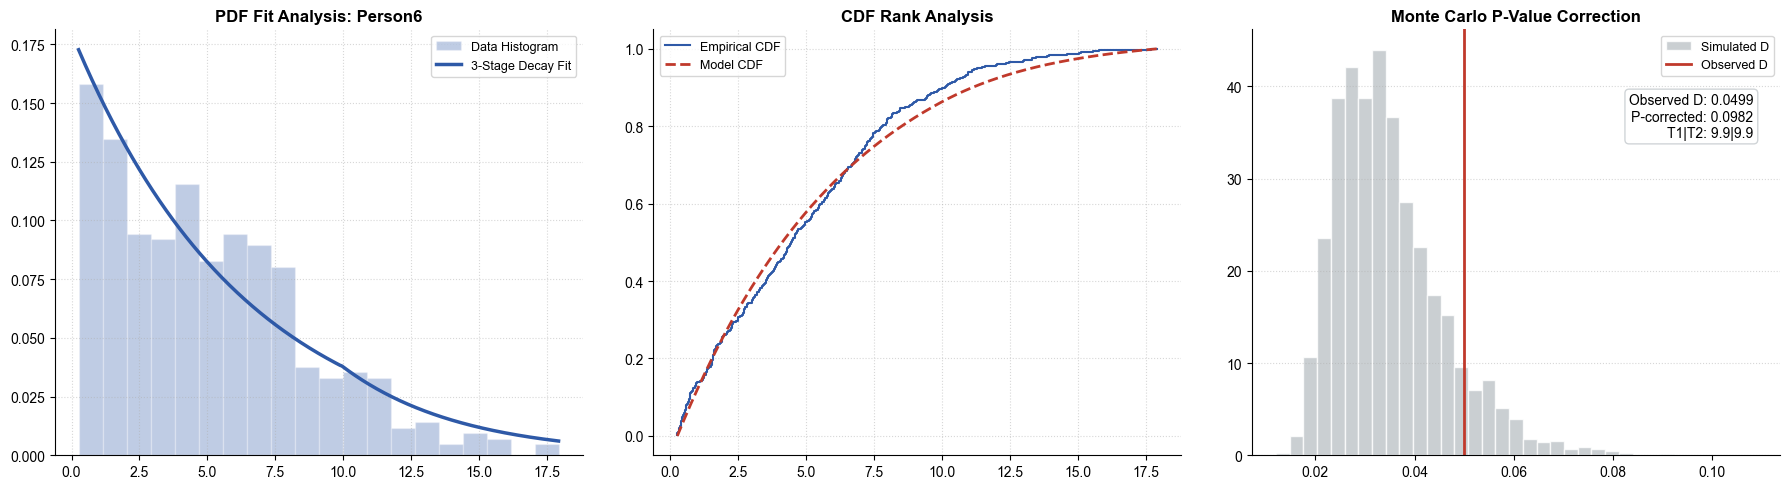

Analysis for Person6 completed. P-corrected: 0.0982


In [33]:
analyze_person_distribution(6)

Running Analysis for Person7...


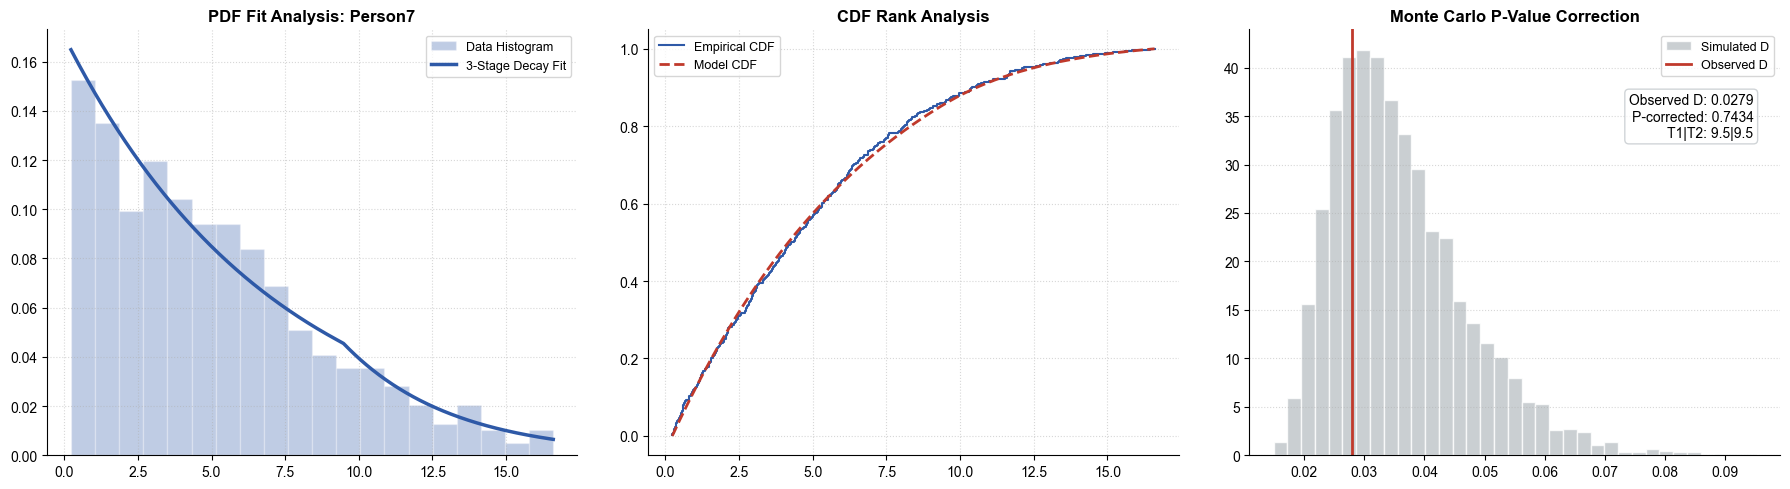

Analysis for Person7 completed. P-corrected: 0.7434


In [35]:
analyze_person_distribution(7)

Running Analysis for Person8...


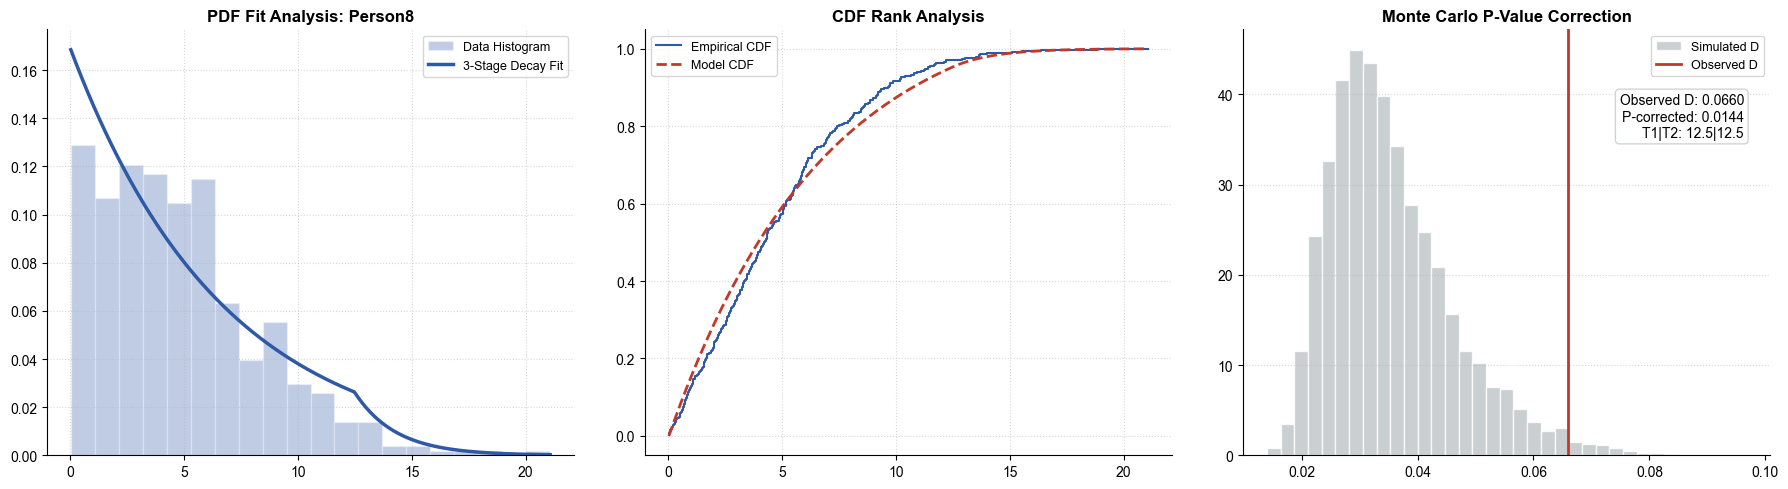

Analysis for Person8 completed. P-corrected: 0.0144


In [34]:
analyze_person_distribution(8)

由P值可知这个三段模型对于X_i(1< i < 7)的拟合效果是非常好的。当i变大时，均匀分布的区间退化为0，整个X_i分布退化为近似于指数分布。而最后一个人的分布不能用三段式模型拟合也是可以想见的，因为最后一个人（Person 8）的金额分布与前七个人有着本质的区别。虽然我们在代码中可以强行用三段式模型去拟合，但在理论层面，这种拟合通常是失效或不合理的。
### 1. 自由度的丧失（Fixed Sum Constraint）
在概率论中，如果 8 个人的金额总和是一个常数 $S$（即 $X_1 + X_2 + ... + X_8 = S$），那么这 8 个随机变量之间存在**强烈的负相关性**。
*   **前 7 个人**：在分配时通常具有较高的“自由度”。即使他们也受总额限制，但单个人领取的金额相对总额较小，其分布更多地取决于分配机制本身（例如你的三段式：初始滑落、中间平台、末尾衰减）。
*   **最后一个人**：其金额 $X_8 = S - \sum_{i=1}^{7} X_i$。这意味着 Person 8 **完全没有自主的分布规律**。他不是被某种“分配逻辑”产生的，而是被前 7 个人“挤”出来的剩余物。在统计学上，他的自由度为 0。

### 2. 分布的卷积效应（Convolution & CLT）
根据独立随机变量之和的性质：
*   如果前 7 个人的金额 $X_1, ..., X_7$ 分别服从某种三段式分布，那么它们的和 $Y = \sum_{i=1}^{7} X_i$ 的分布是这 7 个分布的**卷积（Convolution）**。
*   根据**中心极限定理（Central Limit Theorem）**，多个独立分布（即便是非正态的）之和会迅速趋向于**正态分布**。
*   因此，$X_8 = S - Y$ 的分布本质上是一个“常数减去一个近似正态分布的变量”，其结果更接近于一个**截断正态分布**，而不是具有明显“滑梯-平台-滑梯”特征的三段式分布。


### 3. 边界条件的强约束（Boundary Sensitivity）
三段式模型假设分布的边界 $[a, b]$ 是由物理限制或模型预设的。
*   对于 Person 1，他的上限 $b$ 可能是总额的某个百分比。
*   对于 Person 8，他的上限 $b$ 和下限 $a$ 在每一轮实验中都在**动态剧烈波动**（取决于前 7 个人的结果）。用一个固定的三段式模型（参数固定的 $\tau_1, \tau_2$）去拟合一个边界时刻在变动的变量，必然会导致拟合优度（P-value）极低。

### 总结：为什么不能拟合？
**独立性假设失效**：我们的三段式 MLE 拟合算法假设每一轮实验的 $x_i$ 是独立同分布抽样的结果。但 Person 8 的 $x_i$ 实际上是前 7 个人抽样后的**补数**。
*   **Person 1** 反映的是“原始分配意志”。
*   **Person 8** 反映的是“总额清算压力”。
。